### Windowing: Groups timestamps into windows of window_size (e.g., 10). This reduces input dimensionality and preserves temporal structure.

### Flattening: Converts (samples, windows, features) → (samples, windows*features) for Random Forest.

### Random Forest: Trains a multi-output regressor for a specific bending angle.

### Permutation importance: Measures how shuffling each input feature affects prediction error.

### Window-level aggregation: Averages feature importance within each window.

### Plot: Shows which time windows are most critical for the selected angle.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


In [94]:
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
targets

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,2,0.022017,0.319825,0.363018,0.600159,0.372211
2,2,0.044033,0.319035,0.401244,0.560835,0.412939
3,2,0.066050,0.317768,0.438220,0.522651,0.452336
4,2,0.088067,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
14558,318,0.902686,0.641596,0.373375,0.680266,0.314326
14559,318,0.924703,0.640550,0.372634,0.680719,0.313536
14560,318,0.946720,0.640334,0.374073,0.679194,0.315070
14561,318,0.968736,0.641037,0.377992,0.675413,0.319245


In [109]:

groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)

X = np.array(groups, dtype=float)
print("Shape:", X.shape, y.shape)  

Shape: (315, 1743, 17) (315, 47, 5)


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.9s


building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_j

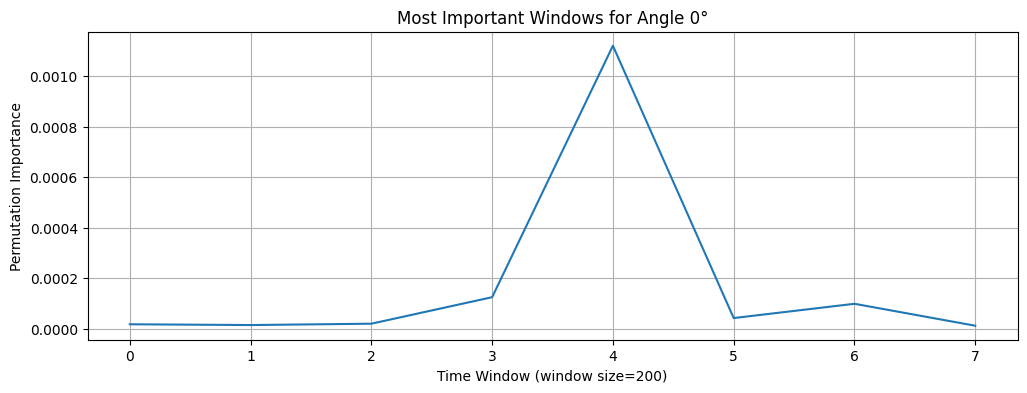

In [110]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt


# ---------------------------
# 2. Windowing Function
# ---------------------------
def window_average(X, window_size=10):
    """
    Aggregate timestamps into non-overlapping windows by averaging.
    """
    num_samples, seq_in, num_features = X.shape
    n_windows = seq_in // window_size
    X_windowed = X[:, :n_windows*window_size, :].reshape(num_samples, n_windows, window_size, num_features)
    X_windowed = X_windowed.mean(axis=2)  # average over time in each window
    return X_windowed, n_windows

window_size = 200
X_win, n_windows = window_average(X, window_size=window_size)

# ---------------------------
# 3. Flatten windows for Random Forest
# ---------------------------
num_samples, n_windows, num_features = X_win.shape
X_flat = X_win.reshape(num_samples, n_windows * num_features)

# ---------------------------
# 4. Select target angle (e.g., angle 25)
# ---------------------------
angle_idx = 0
Y_angle = Y[:, angle_idx, :]  # shape: (num_samples, 5)

# ---------------------------
# 5. Train Random Forest
# ---------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42, verbose=2)
rf.fit(X_flat, Y_angle)

# ---------------------------
# 6. Permutation Importance
# ---------------------------
result = permutation_importance(
    rf, X_flat, Y_angle,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)

# Importance shape: (n_windows*num_features,)
importance = result.importances_mean
# Aggregate importance per window
importance_per_window = importance.reshape(n_windows, num_features).mean(axis=1)

# ---------------------------
# 7. Plot most important windows
# ---------------------------
plt.figure(figsize=(12,4))
plt.plot(importance_per_window)
plt.xlabel(f"Time Window (window size={window_size})")
plt.ylabel("Permutation Importance")
plt.title(f"Most Important Windows for Angle {angle_idx}°")
plt.grid(True)
plt.show()
